# KNN y DMIN utilizando el conjunto de datos de cancer de mama

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer


## 2. Carga y limpieza de datos


In [ ]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

### Manejo de valores faltantes


In [ ]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

## 3. Preprocesamiento


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Aplicar PCA para visualización


In [5]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

## 4. División de datos


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

## 5. Implementación personalizada de DMIN (Clasificador por Distancia Mínima a Centros)


In [7]:
class DMINClassifier:
    def __init__(self):
        self.centroids = []
        self.classes = []

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.centroids = [np.mean(X[y == cls], axis=0) for cls in self.classes]

    def predict(self, X):
        return [self.classes[np.argmin([np.linalg.norm(x - centroid) for centroid in self.centroids])] for x in X]

## 6. Entrenamiento de modelos
### KNN con diferentes valores de k

In [8]:
k_values = [1, 3, 5, 7, 9]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train[:, :2], y_train)  # Usar solo 2D para entrenamiento
    y_pred = knn.predict(X_test[:, :2])
    acc = accuracy_score(y_test, y_pred)
    knn_accuracies.append(acc)


### DMIN

In [9]:

dmin = DMINClassifier()
dmin.fit(X_train[:, :2], y_train)
y_pred_dmin = dmin.predict(X_test[:, :2])
acc_dmin = accuracy_score(y_test, y_pred_dmin)

## 7. Visualización 2D


In [10]:
def plot_decision_boundaries(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    if isinstance(model, KNeighborsClassifier):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = np.array(model.predict(np.c_[xx.ravel(), yy.ravel()]))

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    ax.set_title(title)


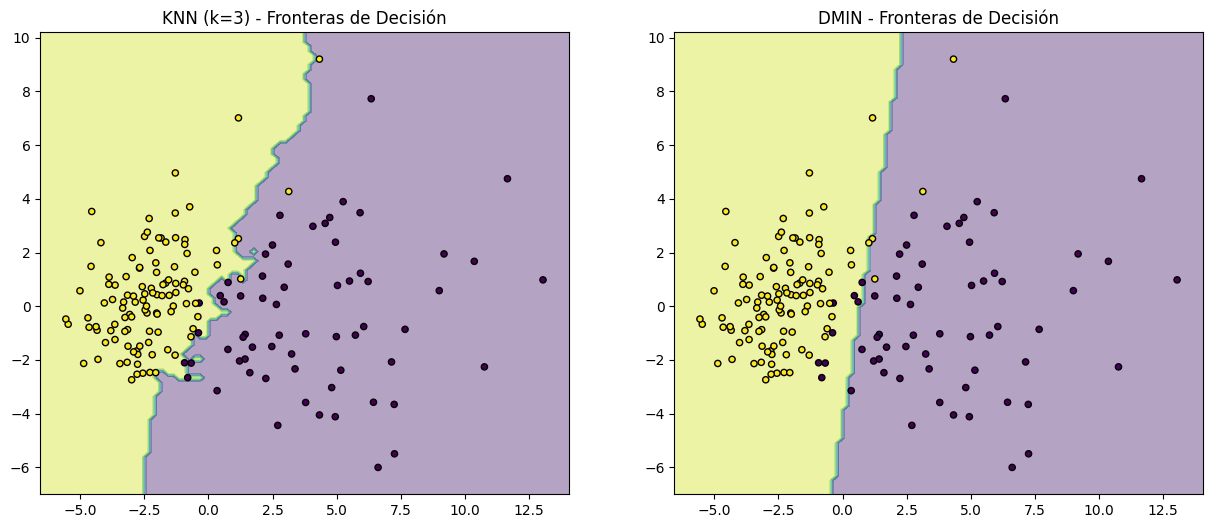

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# KNN (k=3)
knn_best = KNeighborsClassifier(n_neighbors=3)
knn_best.fit(X_train[:, :2], y_train)
plot_decision_boundaries(knn_best, X_test[:, :2], y_test, 'KNN (k=3) - Fronteras de Decisión', axes[0])

# DMIN
plot_decision_boundaries(dmin, X_test[:, :2], y_test, 'DMIN - Fronteras de Decisión', axes[1])


## 8. Visualización 3D


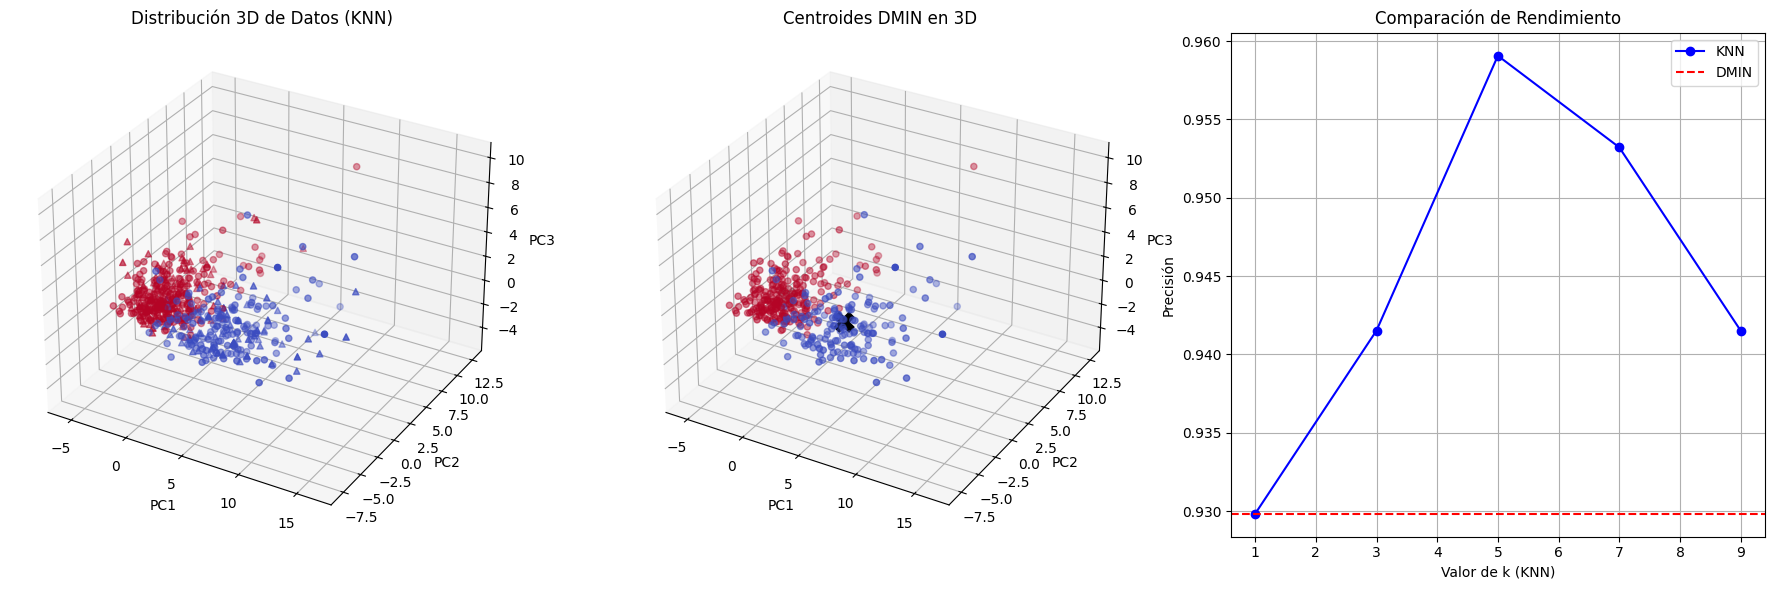

In [12]:
fig = plt.figure(figsize=(18, 6))

# KNN 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, cmap='coolwarm', label='Entrenamiento')
ax1.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=y_test, marker='^', cmap='coolwarm', label='Prueba')
ax1.set_title('Distribución 3D de Datos (KNN)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')

# DMIN 3D
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=y_train, cmap='coolwarm')
ax2.scatter(np.array(dmin.centroids)[:, 0],
            np.array(dmin.centroids)[:, 1],
            [0, 0], s=200, marker='X', color='black')
ax2.set_title('Centroides DMIN en 3D')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

# Comparación de precisión
ax3 = fig.add_subplot(133)
ax3.plot(k_values, knn_accuracies, 'bo-', label='KNN')
ax3.axhline(acc_dmin, color='r', linestyle='--', label='DMIN')
ax3.set_xlabel('Valor de k (KNN)')
ax3.set_ylabel('Precisión')
ax3.set_title('Comparación de Rendimiento')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

## 9. Resultados detallados


In [13]:
print(f"\n{'='*40}\nResultados Finales:\n{'='*40}")
print(f"Mejor KNN (k=3): Exactitud = {max(knn_accuracies):.4f}")
print(f"DMIN: Exactitud = {acc_dmin:.4f}")
print(f"Varianza explicada por componentes PCA: {pca.explained_variance_ratio_[:3]}")




Resultados Finales:
Mejor KNN (k=3): Exactitud = 0.9591
DMIN: Exactitud = 0.9298
Varianza explicada por componentes PCA: [0.44272026 0.18971182 0.09393163]


### Matriz de confusión


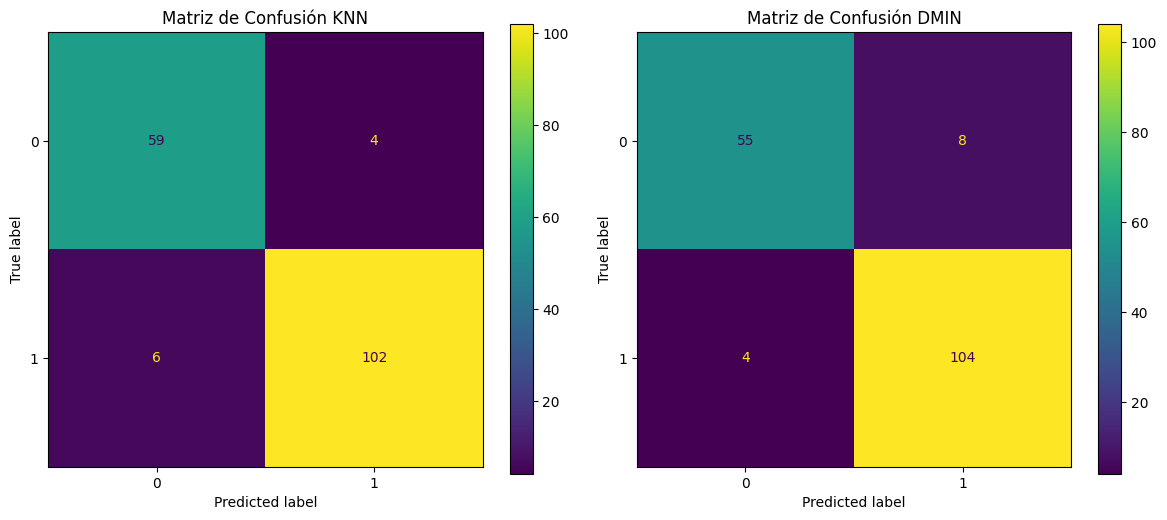

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(knn_best, X_test[:, :2], y_test, ax=ax[0])
ax[0].set_title('Matriz de Confusión KNN')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dmin, ax=ax[1])
ax[1].set_title('Matriz de Confusión DMIN')

plt.tight_layout()
plt.show()